In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import soundfile as sf
from fractions import Fraction
from scipy.signal import resample_poly as res_poly


audio = 'audio_music.mp3'
fs_hz = 240000.0 #abtastrate
duration = 0.5 #sekunden
pilot = 19000
freq_hub = 75000
freq_cutoff = 15000

freq_send = 89.5e6
c = 3e8

print('loaded')

loaded


In [3]:
# Audio einelesen und in L und R aufteilen

data, fs_file = sf.read(audio, dtype="float64", always_2d=True)
left = data[:, 0]
right = data[:, 1] 

print('Abtastrate: ', fs_file, 'Hz')
print('Dauer: ', round(len(left)/fs_file, 2), 's')

Abtastrate:  44100 Hz
Dauer:  34.32 s


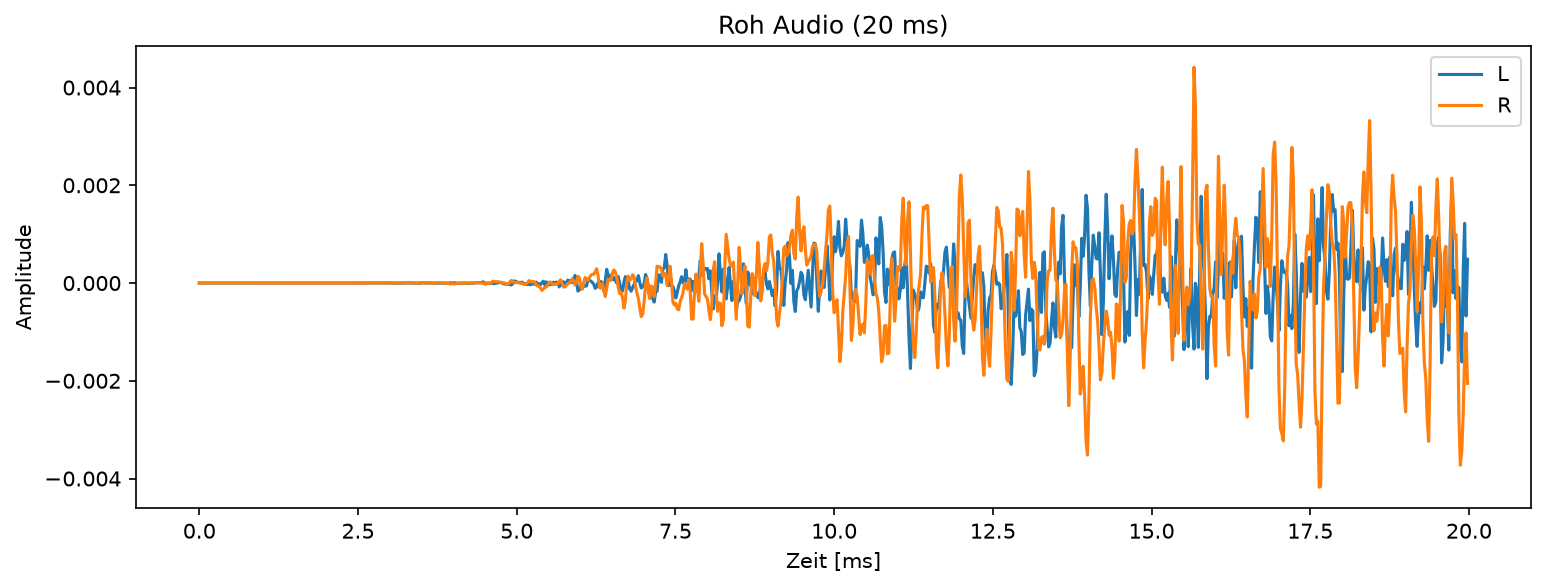

In [4]:
# Wellenform 20ms
fig, ax = plt.subplots(figsize=(12, 4), dpi =150)
n = int(0.02 * fs_file) 
t = np.arange(n) / fs_file * 1e3

plt.plot(t, left[:n], label = 'L')
plt.plot(t, right[:n], label= 'R')
plt.xlabel('Zeit [ms]')
plt.ylabel('Amplitude')
plt.title('Roh Audio (20 ms)')
plt.legend()





In [5]:
# resample auf 240kHz
def res(x, fs_in, fs_out):
    #p/q
    ratio = Fraction(int(fs_out), int(fs_in))
    return res_poly(x, up=ratio.numerator, down=ratio.denominator)

left = res(left, fs_file, fs_hz)
right = res(right, fs_file, fs_hz)

m = int(duration * fs_hz)
left, right = left[:m], right[:m]

peak = max(np.max(np.abs(left)), np.max(np.abs(right)))
left, right = left / peak, right / peak


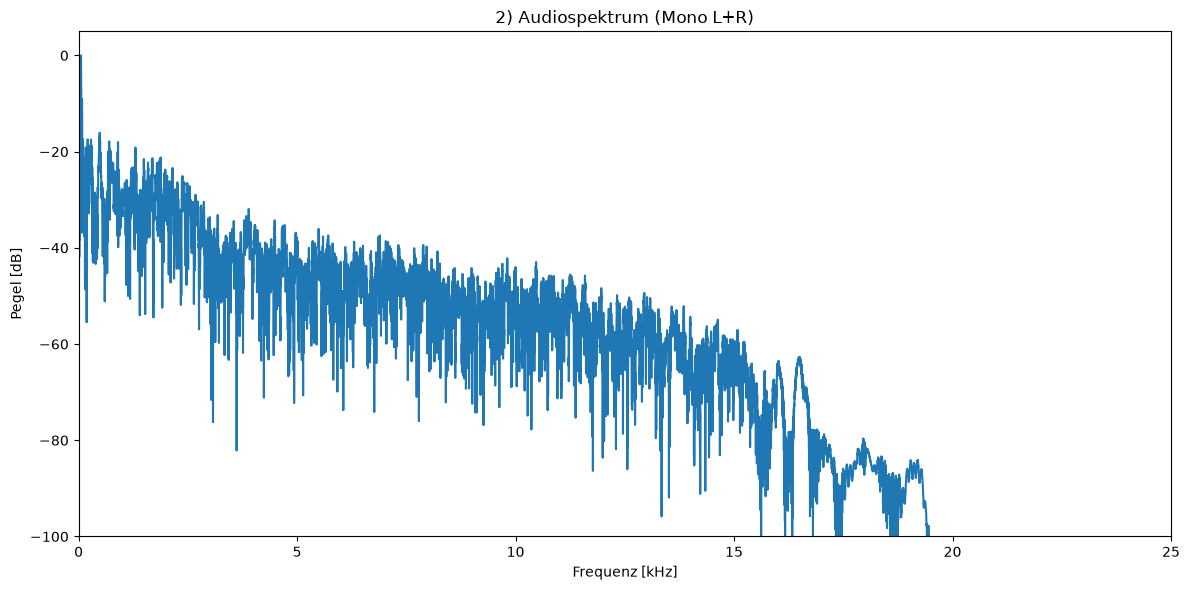

In [6]:
# Spektrum plotten zur Veranschaulichung

def plot_spec(x, fs, fmax=None, title=''):
    X = np.fft.rfft(x * np.hanning(len(x)))
    f = np.fft.rfftfreq(len(x), 1.0/fs)
    magdb = 20 * np.log10(np.abs(X) + 1e-12)
    magdb -= magdb.max()

    fig, ax = plt.subplots(figsize=(12, 6))
    plt.plot(f/1e3, magdb)                 
    if fmax: plt.xlim(0, fmax/1e3)
    plt.ylim(-100, 5)
    plt.xlabel('Frequenz [kHz]'); plt.ylabel('Pegel [dB]'); plt.title(title)

plot_spec(0.5*(left+right), fs_hz, fmax=25e3, title='2) Audiospektrum (Mono L+R)')
plt.tight_layout(); plt.show()


In [7]:
# Stereo Multiplex

t = np.arange(len(left)) / fs_hz

mono = 0.5 * (left + right)
diff = 0.5 * (left - right)
subc = np.sin(4.0 * np.pi * pilot * t)
pilot_ = np.sin(2.0 * np.pi * pilot * t)

mpx = 0.9 * (mono + diff * subc) + 0.1 *pilot_ 

print('wertebereich: [%.3f, %.3f]' % (mpx.min(), mpx.max()))
print(mpx.shape)

wertebereich: [-0.978, 0.948]
(120000,)


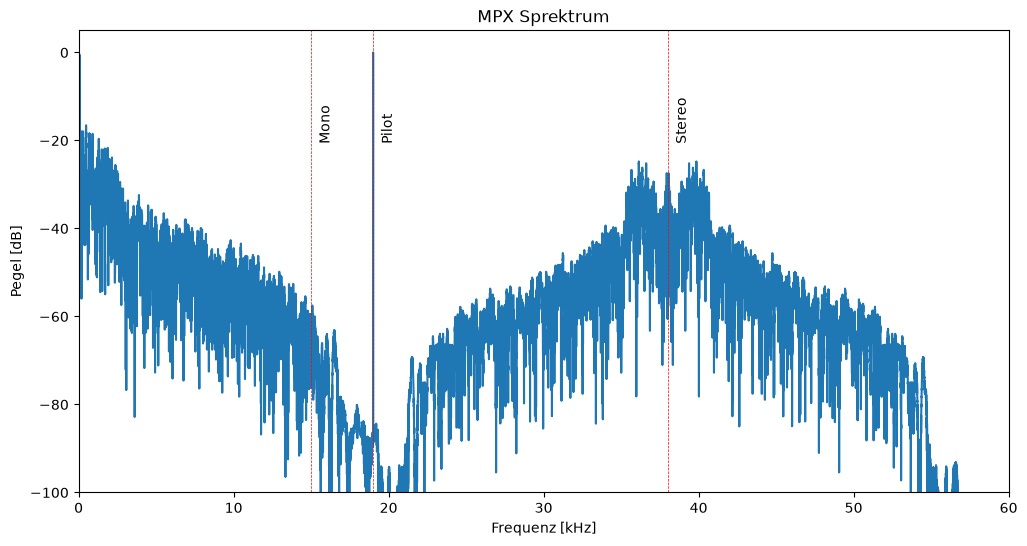

In [8]:
plot_spec(mpx, fs_hz, fmax = 60e3, title = 'MPX Sprektrum')
for fx, name in [(15, 'Mono'), (19, 'Pilot'),(38, 'Stereo')]:
    plt.axvline(fx, color='r', ls='--', lw = 0.5)
    plt.text(fx+0.5, -20, name, rotation=90)

In [9]:
# Momentanfreq = Delta_f * m(t)   -> Delta_f = 75kHz
# Phase = Integal der frequenz (cumsum)
# s(t) = e^(j*phi(t)) = cos(phi(t)) + j*sin(phi(t))

from matplotlib.pylab import cumsum


mom_f = freq_hub * mpx
phase = 2.0 * np.pi *cumsum(mom_f) / fs_hz
s = np.exp(1j * phase)

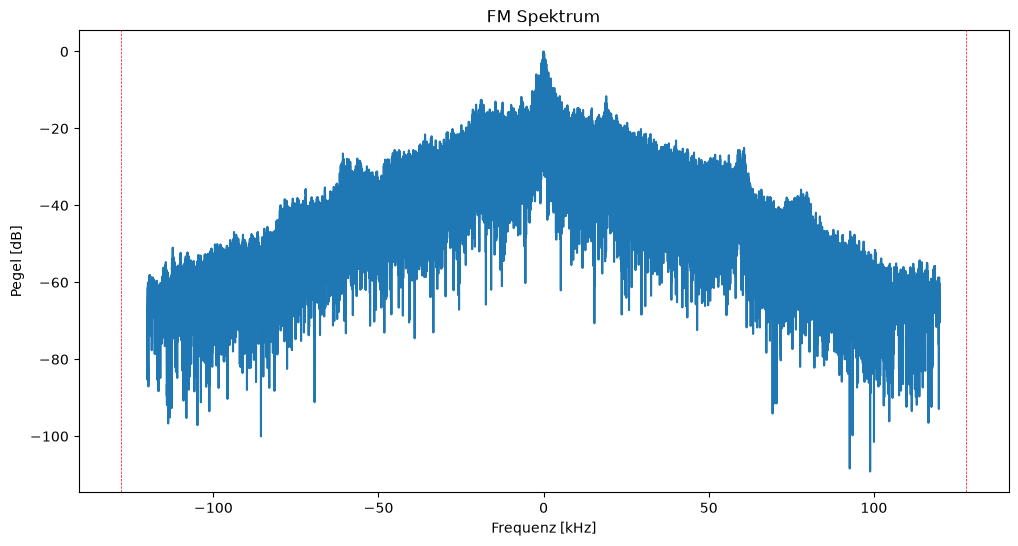

In [15]:
# Carson Bandbreite B = 2 * (Delta_f + fmax) 
fmax = 2 * pilot + freq_cutoff
B = 2 * (freq_hub + fmax)
S = np.fft.fftshift(np.fft.fft(s * np.hanning(len(s))))
f = np.fft.fftshift(np.fft.fftfreq(len(s), 1.0/fs_hz))

mag = 20*np.log10(np.abs(S)+1e-12)
mag -= mag.max()
fig, ax = plt.subplots(figsize=(12, 6))
plt.axvline(B/2/1e3, color='r', linestyle='--', linewidth=0.5)
plt.axvline(-B/2/1e3, color='r', linestyle='--', linewidth=0.5)
plt.title('FM Spektrum')
plt.xlabel('Frequenz [kHz]'); plt.ylabel('Pegel [dB]')

plt.plot(f/1e3, mag)

In [22]:
# a_n = exp(j*alpha_n)
N = 7
d_l = 0.4
Tx_pos = (-5000, 3000)
Rx_pos = (-1000, 500)

lam = c / freq_send
d = d_l * lam
r = d / (2.0 * np.sin(np.pi/N))

phi_elem = 2 * np.pi * np.arange(N) / N
pos = np.stack([r*np.cos(phi_elem), r*np.sin(phi_elem)], axis=1)

phi_tx = np.arctan2(Tx_pos[1]-Rx_pos[1], Tx_pos[0]-Rx_pos[0])
alpha = (2*np.pi/lam) * r * np.cos(phi_elem - phi_tx)
a = np.exp(1j * alpha)

print('lambda: %.2f m, d: %.2f m, r: %.2f m' % (lam, d, r))
print('Azimuth zum Sender: %3f°' % np.degrees(phi_tx))
print('Steering Vektor: ', np.round(a, 2))

lambda: 3.35 m, d: 1.34 m, r: 1.55 m
Azimuth zum Sender: 147.994617°
Steering Vektor:  [-0.77-0.63j  0.95-0.33j -0.45+0.89j -0.97+0.26j  0.02+1.j    0.58-0.81j
 -0.92-0.4j ]


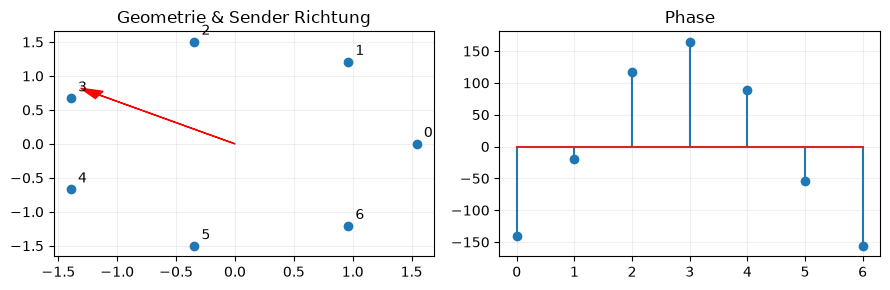

In [46]:
fig, ax =plt.subplots(1,2 , figsize=(9,3))
ax[0].scatter(pos[:,0], pos[:,1], c='tab:blue', zorder=3)
for i,(x,y) in enumerate(pos):
    ax[0].annotate(str(i), (x,y), textcoords='offset points', xytext=(5,5))

ax[0].arrow(0,0, np.cos(phi_tx)*r, np.sin(phi_tx)*r, color='r',
            head_width=r*0.08, length_includes_head=True)
ax[0].set_title('Geometrie & Sender Richtung')
ax[0].grid(alpha = 0.2)
ax[1].grid(alpha = 0.2)
ax[1].stem(np.arange(N), np.degrees(np.angle(a)))
ax[1].set_title('Phase')
plt.tight_layout()
